In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# Define constants
image_size = (224, 224)
patch_size = 16  # Standard ViT patch size
embed_dim = 64  # Embedding dimension
num_heads = 4  # Number of attention heads
transformer_layers = 6  # Number of transformer blocks
mlp_units = [128, 64]  # Feedforward layers in transformer block
mlp_head_units = [256, 128]  # MLP classifier head
num_classes = 10
batch_size = 64
num_patches = (image_size[0] // patch_size) ** 2  # Compute number of patches

In [3]:
print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.6.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# Dataset paths
train_path = r'D:\Project\data_kaggle\aug\train_split'
val_path = r"D:\Project\data_kaggle\aug\val_split"
test_path = r"D:\Project\data_kaggle\test"

In [5]:
# Load datasets
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_path, seed=42, image_size=image_size, batch_size=batch_size)

val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    val_path, seed=42, image_size=image_size, batch_size=batch_size)

Found 5863 files belonging to 8 classes.
Found 1469 files belonging to 8 classes.


In [6]:
# Normalize dataset
normalization_layer = layers.Rescaling(1.0 / 255)
train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
val_dataset = val_dataset.map(lambda x, y: (normalization_layer(x), y))

In [7]:
# Data Augmentation
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
])

In [8]:
# MLP block
def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=tf.nn.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x

# Vision Transformer Model
def vit_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    # Convert image to patches
    patches = layers.Conv2D(embed_dim, kernel_size=patch_size, strides=patch_size, padding="valid")(inputs)
    patches = layers.Reshape((num_patches, embed_dim))(patches)

    # Add trainable class token ([CLS] token)
    cls_token = tf.Variable(tf.zeros((1, 1, embed_dim)), trainable=True)
    cls_tokens = tf.tile(cls_token, [tf.shape(patches)[0], 1, 1])
    x = tf.concat([cls_tokens, patches], axis=1)  # Prepend CLS token

    # Positional Embeddings
    positions = tf.range(start=0, limit=num_patches + 1, delta=1)
    pos_embedding = layers.Embedding(input_dim=num_patches + 1, output_dim=embed_dim)(positions)
    x = x + pos_embedding

    # Transformer blocks
    for _ in range(transformer_layers):
        x_norm = layers.LayerNormalization(epsilon=1e-6)(x)
        attention_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim // num_heads)(x_norm, x_norm)
        x = layers.Add()([x, attention_output])  # Residual Connection

        x_norm = layers.LayerNormalization(epsilon=1e-6)(x)
        mlp_output = mlp(x_norm, hidden_units=mlp_units, dropout_rate=0.1)
        x = layers.Add()([x, mlp_output])  # Residual Connection

    # Use CLS token for classification
    x = layers.LayerNormalization(epsilon=1e-6)(x[:, 0, :])  # Extract CLS token
    x = layers.Dropout(0.5)(x)
    x = mlp(x, hidden_units=mlp_head_units, dropout_rate=0.5)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return models.Model(inputs, outputs)

# Create ViT model
vit_classifier = vit_model((image_size[0], image_size[1], 3), num_classes)
vit_classifier.summary()

The following Variables were used a Lambda layer's call (tf.tile), but
are not present in its tracked objects:
  <tf.Variable 'Variable:0' shape=(1, 1, 64) dtype=float32>
It is possible that this is intended behavior, but it is more likely
an omission. This is a strong indication that this layer should be
formulated as a subclassed Layer rather than a Lambda layer.
Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 224, 224, 3) 0                                            
__________________________________________________________________________________________________
conv2d (Conv2D)                 (None, 14, 14, 64)   49216       input_1[0][0]                    
__________________________________________________________________________________________________
reshape (Reshape)      

In [9]:
# Training function
def run_experiment(model, train_data, val_data, num_epochs=10):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=["accuracy"]
    )

    history = model.fit(train_data, validation_data=val_data, epochs=num_epochs)
    return history

# Train Model
num_epochs = int(input("Enter number of epochs: "))
history = run_experiment(vit_classifier, train_dataset, val_dataset, num_epochs)

Enter number of epochs:  30


Epoch 1/30
92/92 [==============================] - 53s 295ms/step - loss: 2.4293 - accuracy: 0.1414 - val_loss: 2.1580 - val_accuracy: 0.1545
Epoch 2/30
92/92 [==============================] - 27s 274ms/step - loss: 2.3001 - accuracy: 0.1399 - val_loss: 2.1420 - val_accuracy: 0.2063
Epoch 3/30
92/92 [==============================] - 27s 270ms/step - loss: 2.2533 - accuracy: 0.1477 - val_loss: 2.1337 - val_accuracy: 0.2035
Epoch 4/30
92/92 [==============================] - 27s 275ms/step - loss: 2.2210 - accuracy: 0.1479 - val_loss: 2.1275 - val_accuracy: 0.1974
Epoch 5/30
92/92 [==============================] - 27s 275ms/step - loss: 2.1995 - accuracy: 0.1521 - val_loss: 2.1145 - val_accuracy: 0.2097
Epoch 6/30
92/92 [==============================] - 27s 275ms/step - loss: 2.1763 - accuracy: 0.1533 - val_loss: 2.1060 - val_accuracy: 0.2076
Epoch 7/30
92/92 [==============================] - 27s 279ms/step - loss: 2.1618 - accuracy: 0.1552 - val_loss: 2.0941 - val_accuracy: 0.2110

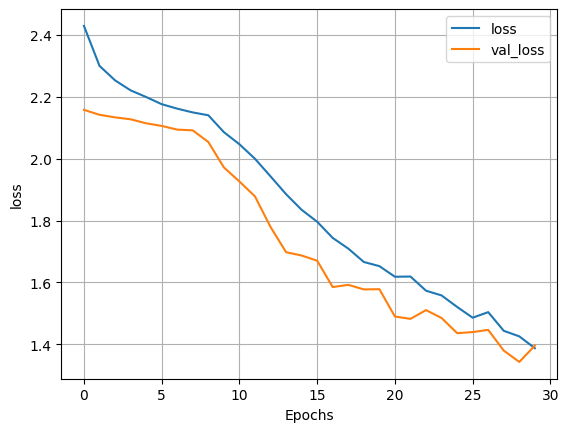

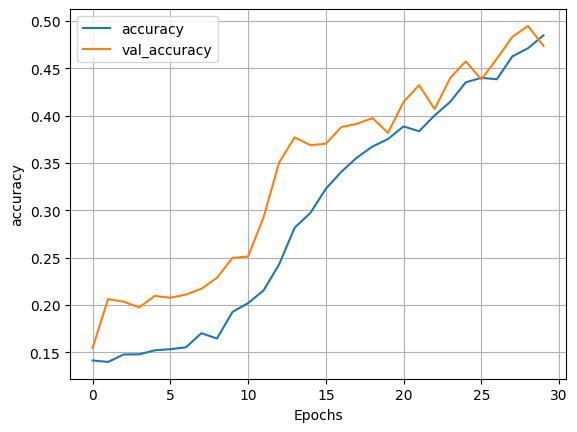

In [10]:
# Plot Training History
def plot_history(history, metric):
    plt.plot(history.history[metric], label=metric)
    plt.plot(history.history["val_" + metric], label="val_" + metric)
    plt.xlabel("Epochs")
    plt.ylabel(metric)
    plt.legend()
    plt.grid()
    plt.show()

plot_history(history, "loss")
plot_history(history, "accuracy")

In [11]:
# Evaluate Model
_, test_accuracy = vit_classifier.evaluate(val_dataset)
print(f"Test accuracy: {round(test_accuracy * 100, 2)}%")

23/23 [==============================] - 4s 127ms/step - loss: 1.3961 - accuracy: 0.4738
Test accuracy: 47.38%


In [12]:
# Load Test Data
test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_path, seed=42, image_size=image_size, batch_size=batch_size)

Found 190 files belonging to 8 classes.


In [13]:
# Predictions
y_true = np.concatenate([y for _, y in test_dataset], axis=0)
y_pred = np.argmax(vit_classifier.predict(test_dataset), axis=1)

In [14]:
# Print Classification Report
print("\nClassification Report:\n", classification_report(y_true, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.29      0.07      0.11        28
           1       0.00      0.00      0.00        21
           2       0.07      0.20      0.10        25
           3       0.00      0.00      0.00        23
           4       0.00      0.00      0.00        21
           5       0.14      0.39      0.20        23
           6       0.03      0.04      0.03        26
           7       0.00      0.00      0.00        23

    accuracy                           0.09       190
   macro avg       0.07      0.09      0.06       190
weighted avg       0.07      0.09      0.06       190



C:\Users\mohan\anaconda3\envs\gpu\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\mohan\anaconda3\envs\gpu\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\mohan\anaconda3\envs\gpu\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [15]:
# Load datasets again to get class names
raw_train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_path, seed=42, image_size=image_size, batch_size=batch_size)

# Extract class names correctly
class_labels = raw_train_dataset.class_names

# Confusion Matrix
conf_mat = confusion_matrix(y_true, y_pred)
class_labels = raw_train_dataset.class_names

Found 5863 files belonging to 8 classes.


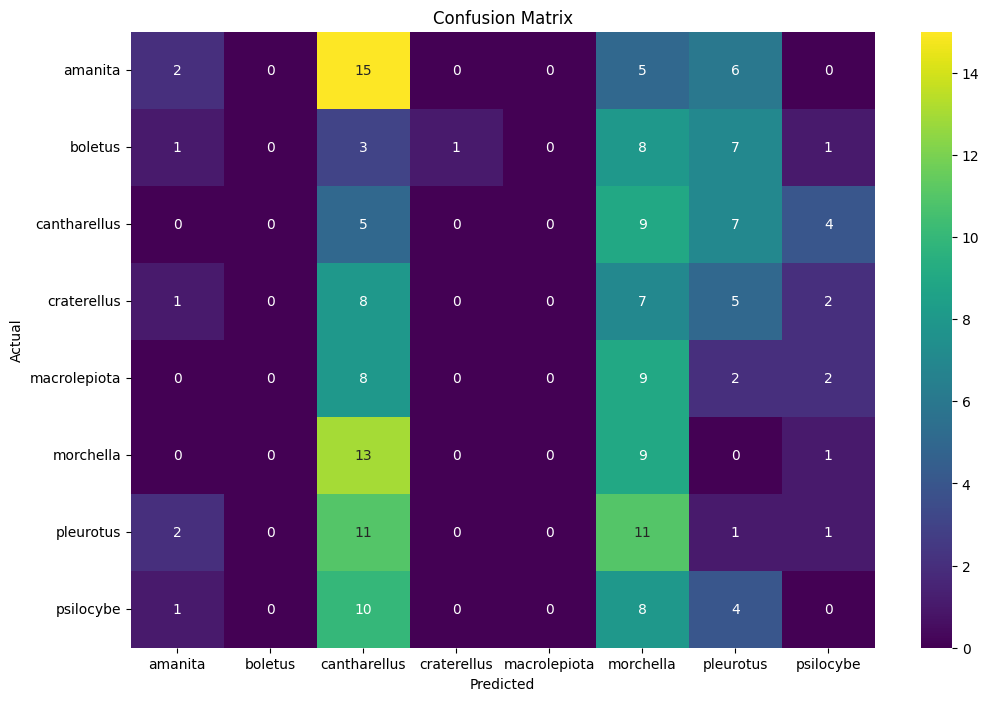

In [16]:
plt.figure(figsize=(12, 8))
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="viridis", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [17]:
model_version = num_epochs
next_version = str(int(model_version) + 10)

import shutil

notebook_filename = f"{model_version}_ADAM.ipynb"
new_notebook_filename = f"{next_version}_ADAM.ipynb"

shutil.copy(notebook_filename, new_notebook_filename)
print(f"Notebook copied as {new_notebook_filename}")

Notebook copied as 40_ADAM.ipynb


In [ ]:
import os
os._exit(00)